# 强化学习实验
强化学习是一个理论与实践相结合的机器学习分支，我们不仅要理解它算法背后的一些数学原理，还要通过上机实践实现算法。在很多实验环境里面去探索算法能不能得到预期效果也是一个非常重要的过程。

我们可以使用 Python 和深度学习的一些包来实现强化学习算法。现在有很多深度学习的包可以使用，比如 PyTorch、TensorFlow、Keras，熟练使用其中的两三种，就可以实现非常多的功能。所以我们并不需要从头去“造轮子”。

## Gym
OpenAI是一家非营利性的人工智能研究公司，其公布了非常多的学习资源以及算法资源。其之所以叫作 OpenAI，他们把所有开发的算法都进行了开源。 如图 1.24 所示，OpenAI 的 Gym库是一个环境仿真库，里面包含很多现有的环境。针对不同的场景，我们可以选择不同的环境。离散控制场景（输出的动作是可数的，比如Pong游戏中输出的向上或向下动作）一般使用雅达利环境评估；连续控制场景（输出的动作是不可数的，比如机器人走路时不仅有方向，还有角度，角度就是不可数的，是一个连续的量 ）一般使用 MuJoCo 环境评估。Gym Retro是对 Gym 环境的进一步扩展，包含更多的游戏。

我们可以通过 pip 来安装 Gym 库，由于 Gym 库 0.26.0 及其之后的版本对之前的代码不兼容，所以我们安装 0.26.0 之前的 Gym，比如 0.25.2。
`pip install gym==0.25.2`
此外，为了显示图形界面，我们还需要安装 pygame 库。
`pip install pygame`

注意：建议大家在minicoda中创建一个专门的虚拟环境来运行这个项目

比如我们现在安装了Gym库，就可以直接调入Taxi-v3的环境。初始化这个环境后，我们就可以进行交互了。智能体得到某个观测后，它就会输出一个动作。这个动作会被环境拿去执行某个步骤 ，然后环境就会往前走一步，返回新的观测、奖励以及一个 flag 变量 done，done 决定这个游戏是不是结束了。我们通过几行代码就可实现强化学习的框架：

注意，由于是使用的平台环境，运行代码的时候会出现不能显示图形界面，大家可以在本地进行尝试；

In [7]:
pip install gym==0.26.2 -i https://pypi.org/simple/

Looking in indexes: https://pypi.org/simple/

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
!pip install pygame

Looking in indexes: https://mirrors.tencent.com/pypi/simple/

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [9]:
import gym 
env = gym.make("Taxi-v3") 
observation = env.reset() 
agent = load_agent() 
for step in range(100):
    action = agent(observation) 
    observation, reward, done, info = env.step(action)

NameError: name 'load_agent' is not defined

上面这段代码只是示例，其目的是让读者了解强化学习算法代码实现的框架，并非完整代码，load_agent 函数并未定义，所以运行这段代码会报错。

如图 1.25 所示，Gym 库里面有很多经典的控制类游戏。比如 Acrobot需要让一个双连杆机器人立起来；CartPole需要通过控制一辆小车，让杆立起来；MountainCar需要通过前后移动车，让它到达旗帜的位置。在刚开始测试强化学习的时候，我们可以选择这些简单环境，因为强化学习在这些环境中可以在一两分钟之内见到效果。
<div align="center">
<img src="https://datawhalechina.github.io/easy-rl/img/ch1/1.46.png" alt="经典控制问题" width="400" >
</div>
大家可以点[这个链接](https://www.gymlibrary.dev/environments/classic_control/)看一看这些环境。在刚开始测试强化学习的时候，可以选择这些简单环境，因为这些环境可以在一两分钟之内见到一个效果。

如图所示，CartPole-v0 环境有两个动作：将小车向左移动和将小车向右移动。我们还可以得到观测：小车当前的位置，小车当前往左、往右移的速度，杆的角度以及杆的最高点（顶端）的速度。 观测越详细，我们就可以更好地描述当前所有的状态。这里有奖励的定义，如果能多走一步，我们就会得到一个奖励（奖励值为1），所以我们需要存活尽可能多的时间来得到更多的奖励。当杆的角度大于某一个角度（没能保持平衡），或者小车的中心到达图形界面窗口的边缘，或者累积步数大于200，游戏就结束了，我们就输了。所以智能体的目的是控制杆，让它尽可能地保持平衡以及尽可能保持在环境的中央。
<div align="center">
<img src="https://datawhalechina.github.io/easy-rl/img/ch1/1.47.png" alt="经典控制问题" width="400" >
</div>

In [ ]:
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_  # 将bool8指向numpy的原生布尔类型

# 构建环境，指定渲染模式
env = gym.make('CartPole-v1', render_mode='human')

try:
    # 重置环境（新版本gym返回两个值）
    obs, info = env.reset()
    
    # 运行1000步交互
    for step in range(1000):
        # 随机选择动作（0/1）
        action = env.action_space.sample()
        
        # 执行动作，接收所有返回值
        try:
            obs, reward, terminated, truncated, info = env.step(action)
        except Exception as e:
            print(f"第{step}步执行出错：{e}")
            break
        
        # 回合结束时重置环境
        if terminated or truncated:
            print(f"回合结束，重置环境（步数：{step}）")
            obs, info = env.reset()
            
finally:
    # 强制关闭环境，释放资源
    env.close()
    print("CartPole环境已关闭，代码执行完成")

error: XDG_RUNTIME_DIR is invalid or not set in the environment.


回合结束，重置环境（步数：13）
回合结束，重置环境（步数：28）
回合结束，重置环境（步数：54）
回合结束，重置环境（步数：78）
回合结束，重置环境（步数：98）
回合结束，重置环境（步数：122）
回合结束，重置环境（步数：140）
回合结束，重置环境（步数：156）
回合结束，重置环境（步数：174）
回合结束，重置环境（步数：207）
回合结束，重置环境（步数：219）
回合结束，重置环境（步数：229）
回合结束，重置环境（步数：244）
回合结束，重置环境（步数：262）
回合结束，重置环境（步数：309）
回合结束，重置环境（步数：333）
回合结束，重置环境（步数：344）
回合结束，重置环境（步数：368）
回合结束，重置环境（步数：409）
回合结束，重置环境（步数：424）
回合结束，重置环境（步数：440）
回合结束，重置环境（步数：451）
回合结束，重置环境（步数：468）
回合结束，重置环境（步数：487）
回合结束，重置环境（步数：506）
回合结束，重置环境（步数：570）
回合结束，重置环境（步数：601）
回合结束，重置环境（步数：618）
回合结束，重置环境（步数：639）
回合结束，重置环境（步数：663）
回合结束，重置环境（步数：675）
回合结束，重置环境（步数：706）
回合结束，重置环境（步数：737）
回合结束，重置环境（步数：754）
回合结束，重置环境（步数：767）
回合结束，重置环境（步数：800）
回合结束，重置环境（步数：814）
回合结束，重置环境（步数：840）
回合结束，重置环境（步数：850）
回合结束，重置环境（步数：867）
回合结束，重置环境（步数：884）
回合结束，重置环境（步数：912）
回合结束，重置环境（步数：931）
回合结束，重置环境（步数：945）
回合结束，重置环境（步数：961）
回合结束，重置环境（步数：977）
回合结束，重置环境（步数：999）
CartPole环境已关闭，代码执行完成


注意：如果绘制了实验的图形界面窗口，那么关闭该窗口的最佳方式是调用 env.close()。试图直接关闭图形界面窗口可能会导致内存不能释放，甚至会导致死机。

当我们执行这段代码时，机器人会驾驶着小车朝某个方向一直跑，直到我们看不见，这是因为我们还没开始训练机器人。

Gym 库中的大部分小游戏都可以用一个普通的实数或者向量来表示动作。输出env.action_space.sample()的返回值，能看到输出为 1 或者 0。env.action_space.sample()的含义是，在该游戏的所有动作空间里随机选择一个作为输出。在这个例子中，动作只有两个：0 和 1，一左一右。env.step()方法有4个返回值：observation、reward、done、info 。

observation 是状态信息，是在游戏中观测到的屏幕像素值或者盘面状态描述信息。reward 是奖励值，即动作提交以后能够获得的奖励值。这个奖励值因游戏的不同而不同，但总体原则是，对完成游戏有帮助的动作会获得比较高的奖励值。done 表示游戏是否已经完成，如果完成了，就需要重置游戏并开始一个新的回合。info 是一些比较原始的用于诊断和调试的信息，或许对训练有帮助。不过，OpenAI 在评价我们提交的机器人时，是不允许使用这些信息的。

在每个训练中都要使用的返回值有 observation、reward、done。但 observation 的结构会由于游戏的不同而发生变化。以 CartPole-v0 为例，我们对代码进行修改：

In [ ]:
import gym
import numpy as np

# 解决numpy bool8属性缺失问题
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

# 1. 改用CartPole-v1（v0已彻底过时），指定render_mode避免渲染警告
# 2. render_mode='human' 确保图形界面正常显示
env = gym.make('CartPole-v1', render_mode='human')

# 新版Gym的reset()返回2个值（观测值+信息），需完整接收
observation, info = env.reset()

# 仅运行10步
for _ in range(10):
    env.render()  # 显示图形界面
    action = env.action_space.sample()  # 随机选动作
    
   
    observation, reward, terminated, truncated, info = env.step(action)
    

    done = terminated or truncated
    
    # 打印观测值
    print(f"观测值：{observation}，奖励：{reward}，是否结束：{done}")
    
    # 如果回合结束，重置环境（避免后续步骤出错）
    if done:
        observation, info = env.reset()

# 关闭环境
env.close()
print("代码执行完成，环境已关闭")

error: XDG_RUNTIME_DIR is invalid or not set in the environment.


观测值：[ 0.04572926 -0.17466857  0.02228113  0.3152767 ]，奖励：1.0，是否结束：False
观测值：[ 0.04223589 -0.3701007   0.02858666  0.61490226]，奖励：1.0，是否结束：False
观测值：[ 0.03483387 -0.1753896   0.04088471  0.33135825]，奖励：1.0，是否结束：False
观测值：[ 0.03132608 -0.37106895  0.04751187  0.6366488 ]，奖励：1.0，是否结束：False
观测值：[ 0.0239047  -0.17664066  0.06024485  0.35929868]，奖励：1.0，是否结束：False
观测值：[0.02037189 0.01757544 0.06743082 0.08620431]，奖励：1.0，是否结束：False
观测值：[ 0.0207234   0.21166928  0.06915491 -0.18446516]，奖励：1.0，是否结束：False
观测值：[ 0.02495679  0.4057371   0.06546561 -0.45455575]，奖励：1.0，是否结束：False
观测值：[ 0.03307153  0.20975351  0.05637449 -0.14197694]，奖励：1.0，是否结束：False
观测值：[ 0.0372666   0.40402466  0.05353495 -0.4163554 ]，奖励：1.0，是否结束：False
代码执行完成，环境已关闭


从输出可以看出这是一个四维的观测。在其他游戏中会有维度更多的情况出现。

env.step()完成了一个完整的S→A→R→S过程。我们只要不断观测这样的过程，并让智能体在其中用相应的算法完成训练，就能得到一个高质量的强化学习模型。

Gym 库已注册的环境可以通过以下代码查看：

In [33]:
import gym

# 兼容不同Gym版本的方式获取所有环境ID
if hasattr(gym.envs.registry, 'all'):
    # 旧版本Gym (<=0.25)
    env_specs = gym.envs.registry.all()
    env_ids = [env_spec.id for env_spec in env_specs]
else:
    # 新版本Gym (>=0.26)
    # registry是字典，keys()就是环境ID
    env_ids = list(gym.envs.registry.keys())

# 打印前10个环境ID（避免输出过长）
print("前10个可用的Gym环境ID：")
for idx, env_id in enumerate(env_ids[:10]):
    print(f"{idx+1}. {env_id}")

# 打印总数量
print(f"\nGym中总共有 {len(env_ids)} 个环境")

前10个可用的Gym环境ID：
1. CartPole-v0
2. CartPole-v1
3. MountainCar-v0
4. MountainCarContinuous-v0
5. Pendulum-v1
6. Acrobot-v1
7. LunarLander-v2
8. LunarLanderContinuous-v2
9. BipedalWalker-v3
10. BipedalWalkerHardcore-v3

Gym中总共有 44 个环境


Gym 库中的每个环境都定义了观测空间和动作空间。观测空间和动作空间可以是离散的（取值为有限个离散的值），也可以是连续的（取值为连续的值）。

## MountainCar-v0 例子
接下来，我们通过一个例子来学习如何与 Gym 库进行交互。我们选取小车上山（MountainCar-v0）作为例子。

首先我们来看看这个任务的观测空间和动作空间：

In [34]:
import gym
env = gym.make('MountainCar-v0')
print('观测空间 = {}'.format(env.observation_space))
print('动作空间 = {}'.format(env.action_space))
print('观测范围 = {} ~ {}'.format(env.observation_space.low,
        env.observation_space.high))
print('动作数 = {}'.format(env.action_space.n))

观测空间 = Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
动作空间 = Discrete(3)
观测范围 = [-1.2  -0.07] ~ [0.6  0.07]
动作数 = 3


在 Gym 库中，环境的观测空间用 env.observation_space 表示，动作空间用 env.action_space 表示。离散空间 gym.spaces.Discrete 类表示，连续空间用 gym.spaces.Box 类表示。对于离散空间，Discrete (n) 表示可能取值的数量为 n；对于连续空间，Box类实例成员中的 low 和 high 表示每个浮点数的取值范围。MountainCar-v0 中的观测是长度为 2 的 numpy 数组，数组中值的类型为 float。MountainCar-v0 中的动作是整数，取值范围为 {0,1,2}。

接下来实现智能体来控制小车移动，对应代码如下。

In [35]:
class SimpleAgent:
    def __init__(self, env):
        pass
    
    def decide(self, observation): # 决策
        position, velocity = observation
        lb = min(-0.09 * (position + 0.25) ** 2 + 0.03,
                0.3 * (position + 0.9) ** 4 - 0.008)
        ub = -0.07 * (position + 0.38) ** 2 + 0.07
        if lb < velocity < ub:
            action = 2
        else:
            action = 0
        return action # 返回动作

    def learn(self, *args): # 学习
        pass
    
agent = SimpleAgent(env)

SimpleAgent 类的 decide()方法用于决策，learn() 方法用于学习，该智能体不是强化学习智能体，不能学习，只能根据给定的数学表达式进行决策。

接下来我们试图让智能体与环境交互，代码如下。

In [ ]:
def play(env, agent, render=False, train=False):
    episode_reward = 0.  # 记录回合总奖励，初始值为0
    
    observation, info = env.reset(seed=3)  # 设置随机种子，返回(obs, info)
    
    while True:  # 不断循环，直到回合结束
        if render: 
            env.render()  # 显示图形界面（指定render_mode后可省略，仍兼容）
        action = agent.decide(observation)
        
        next_observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward  # 收集回合奖励
        
        if train:  # 判断是否训练智能体
            agent.learn(observation, action, reward, terminated or truncated)
        
        
        if terminated or truncated:
            break
        observation = next_observation
    return episode_reward  # 返回回合总奖励

上面代码中的 play 函数可以让智能体和环境交互一个回合，该函数有 4 个参数。env 是环境类。agent 是智能体类。render 是 bool 型变量，其用于判断是否需要图形化显示。如果 render 为 True，则在交互过程中会调用 env.render() 以显示图形界面，通过调用 env.close() 可关闭图形界面。train 是 bool 型变量，其用于判断是否训练智能体，在训练过程中设置为 True，让智能体学习；在测试过程中设置为 False，让智能体保持不变。该函数的返回值 episode_reward 是 float 型的数值，其表示智能体与环境交互一个回合的回合总奖励。

接下来，我们使用下面的代码让智能体和环境交互一个回合，并显示图形界面。

In [40]:
episode_reward = play(env, agent, render=True)
print('回合奖励 = {}'.format(episode_reward))
env.close()  # 关闭图形界面

回合奖励 = -105.0


为了评估智能体的性能，需要计算出连续交互 100 回合的平均回合奖励，代码如下。

In [41]:
import numpy as np
episode_rewards = [play(env, agent) for _ in range(100)]
print('平均回合奖励 = {}'.format(np.mean(episode_rewards)))

平均回合奖励 = -105.0


SimpleAgent 类对应策略的平均回合奖励在 110 左右，而对于小车上山任务，只要连续 100 个回合的平均回合奖励大于110，就可以认为该任务被解决了。完整代码实现如下

测试智能体在 Gym 库中某个任务的性能时，出于习惯使然，学术界一般最关心 100 个回合的平均回合奖励。对于有些任务，还会指定一个参考的回合奖励值，当连续 100 个回合的奖励大于指定的值时，则认为该任务被解决了。而对于没有指定值的任务，就无所谓任务被解决了或没有被解决。

我们对 Gym 库的用法进行总结：使用 env=gym.make(环境名)取出环境，使用 env.reset()初始化环境，使用 env.step(动作)执行一步环境，使用 env.render()显示环境，使用 env.close()关闭环境。Gym库有对应的[官方文档](https://www.gymlibrary.dev/)，读者可以阅读文档来学习 Gym库 。

In [45]:
import gym
import numpy as np

class SimpleAgent:
    def __init__(self, env):
        pass
    
    def decide(self, observation): # 决策逻辑保持不变
        position, velocity = observation
        lb = min(-0.09 * (position + 0.25) ** 2 + 0.03,
                0.3 * (position + 0.9) ** 4 - 0.008)
        ub = -0.07 * (position + 0.38) ** 2 + 0.07
        if lb < velocity < ub:
            action = 2
        else:
            action = 0
        return action # 返回动作

    def learn(self, *args): # 学习函数保持不变
        pass
    

def play(env, agent, render=False, train=False, seed=3):
    episode_reward = 0. # 记录回合总奖励，初始化为0
    
    observation, info = env.reset(seed=seed) # 替代原有的env.seed(seed)
    while True: # 不断循环，直到回合结束
        if render: # 判断是否显示
            env.render() # 显示图形界面
        action = agent.decide(observation)
        
        next_observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward # 收集回合奖励
        if train: # 判断是否训练智能体
            
            agent.learn(observation, action, reward, terminated or truncated)
       
        if terminated or truncated:
            break
        observation = next_observation
    return episode_reward # 返回回合总奖励

# 主程序

env = gym.make('MountainCar-v0', render_mode="human")
agent = SimpleAgent(env)

# 打印环境信息（保持不变）
print('观测空间 = {}'.format(env.observation_space))
print('动作空间 = {}'.format(env.action_space))
print('观测范围 = {} ~ {}'.format(env.observation_space.low,
        env.observation_space.high))
print('动作数 = {}'.format(env.action_space.n))

# 运行单回合（带渲染）
episode_reward = play(env, agent, render=True)
print('单回合奖励 = {}'.format(episode_reward))

# 运行100回合计算平均奖励
episode_rewards = [play(env, agent, render=False) for _ in range(100)]
print('100回合平均奖励 = {}'.format(np.mean(episode_rewards)))

# 关闭环境
env.close()

观测空间 = Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
动作空间 = Discrete(3)
观测范围 = [-1.2  -0.07] ~ [0.6  0.07]
动作数 = 3
单回合奖励 = -105.0
100回合平均奖励 = -105.0


## 用pytorch实现的深度强化学习
接下来，我们利用Tensorflow和Keras实现一个深度强化学习的项目，在强化学习中，我们需要理解`A-action`,`R-reward`,`E-environment`,`A-agent`这四个基本的概念；
接下来，我们会完成一下三件事情：

1，用Gym创建一个深度强化学习的环境

2，用pytorch创建一个深度学习模型

3，训练模型

4,可视化模型

### 安装环境
首先需要安装以下环境：

pip install pytorch(建议大家看官方文档安装安装库，以免出现不兼容的问题)


### 使用 OpenAI Gym 测试随机环境

In [50]:
import gym 
import random

In [51]:
env = gym.make('CartPole-v0', render_mode="human")
states = env.observation_space.shape[0]
actions = env.action_space.n

In [52]:
print(actions)
print(states)

2
4


In [53]:
episodes = 10
for episode in range(1, episodes+1):
    # 3. 修正reset返回值：接收(state, info)，而非仅state
    state, info = env.reset()
    done = False  # 兼容旧版的done逻辑
    score = 0 
    
    while not done:
        env.render()  # 显示图形界面（指定render_mode后可省略，仍兼容）
        action = random.choice([0, 1])  # 随机选动作：0=左，1=右
        
        # 4. 修正step返回值：接收5个值，合并terminated+truncated为done
        n_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated  # 还原旧版的done逻辑
        score += reward
        
        state = n_state  # 更新状态（可选，这里随机策略用不到，但规范）
    
    print('Episode:{} Score:{}'.format(episode, score))

env.close()  # 关闭图形界面

error: XDG_RUNTIME_DIR is invalid or not set in the environment.


Episode:1 Score:35.0
Episode:2 Score:16.0
Episode:3 Score:12.0
Episode:4 Score:17.0
Episode:5 Score:15.0
Episode:6 Score:22.0
Episode:7 Score:17.0
Episode:8 Score:11.0
Episode:9 Score:42.0
Episode:10 Score:20.0


### 使用 pytorch 创建深度学习模型

In [3]:
import gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import numpy as np

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [5]:
# 创建网络模型
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.linear1 = nn.Linear(input_dim, 128)
        self.linear2 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = torch.relu(self.linear1(x))
        x = self.linear2(x)
        return x


In [20]:
# 创建环境
env = gym.make('CartPole-v1', render_mode="None")
input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n

/root/.pyenv/versions/3.11.1/lib/python3.11/site-packages/gym/envs/registration.py:623: UserWarning: WARN: The environment is being initialised with mode (None) that is not in the possible render_modes (['human', 'rgb_array']).
  logger.warn(


In [7]:

# 创建模型和优化器
model = DQN(input_dim, output_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
model

/root/.pyenv/versions/3.11.1/lib/python3.11/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


DQN(
  (linear1): Linear(in_features=4, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=2, bias=True)
)

In [8]:

# 创建记忆
memory = deque(maxlen=10000)

In [11]:
for episode in range(1500):
    
    reset_result = env.reset()
    if isinstance(reset_result, tuple):
        state, _ = reset_result 
    else:
        state = reset_result     
    # 转换状态为张量并移到指定设备
    state = torch.from_numpy(np.array(state)).float().to(device)
    total_reward = 0  # 记录当前回合总奖励

    for t in range(200):
        # ε-贪心策略选择动作（ε=0.1）
        if random.random() < 0.1:
            action = env.action_space.sample()  # 随机动作
        else:
            action = model(state).argmax().item()  # 模型选最优动作
        
        # 执行动作，适配新旧版Gym的step返回值
        step_result = env.step(action)
        if len(step_result) == 5:
            
            next_state, reward, terminated, truncated, _ = step_result
            done = terminated or truncated  # 合并结束标志
        else:
           
            next_state, reward, done, _ = step_result
        
        # 转换next_state为张量并移到指定设备
        next_state = torch.from_numpy(np.array(next_state)).float().to(device)
        total_reward += reward  # 累加回合奖励

        
        memory.append((
            state.cpu().numpy(), 
            action, 
            reward, 
            next_state.cpu().numpy(), 
            done
        ))
        # 更新当前状态
        state = next_state

        # 回合结束则跳出循环
        if done:
            break

    # 每100回合打印一次训练进度
    if episode % 100 == 0: 
        print(f"Episode {episode}, Total reward: {total_reward}")

    # 经验回放训练（当经验池容量超过100时）
    if len(memory) > 100:
        # 随机采样100条经验
        batch = random.sample(memory, 100)
        batch_state, batch_action, batch_reward, batch_next_state, batch_done = zip(*batch)
        
        # 转换为张量并设置正确类型
        batch_state = torch.from_numpy(np.array(batch_state)).float().to(device)
        batch_action = torch.tensor(batch_action, dtype=torch.long).to(device)
        batch_reward = torch.tensor(batch_reward, dtype=torch.float).to(device)
        batch_next_state = torch.from_numpy(np.array(batch_next_state)).float().to(device)
        batch_done = torch.tensor(batch_done, dtype=torch.float).to(device)
        
        # 计算当前Q值和目标Q值
        q_values = model(batch_state)
        next_q_values = model(batch_next_state)
        
        # 取出对应动作的Q值（修正维度匹配问题）
        q_value = q_values.gather(1, batch_action.unsqueeze(1)).squeeze(1)
        next_q_value = next_q_values.max(1)[0]
        # 计算目标Q值（折扣因子0.99）
        expected_q_value = batch_reward + 0.99 * next_q_value * (1 - batch_done)
        
        # 计算MSE损失并反向传播更新模型
        loss = nn.MSELoss()(q_value, expected_q_value.detach())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()



Episode 0, Total reward: 11.0
Episode 100, Total reward: 10.0
Episode 200, Total reward: 13.0
Episode 300, Total reward: 10.0
Episode 400, Total reward: 28.0
Episode 500, Total reward: 50.0
Episode 600, Total reward: 56.0
Episode 700, Total reward: 36.0
Episode 800, Total reward: 34.0
Episode 900, Total reward: 26.0
Episode 1000, Total reward: 65.0
Episode 1100, Total reward: 54.0
Episode 1200, Total reward: 30.0
Episode 1300, Total reward: 31.0
Episode 1400, Total reward: 109.0


In [14]:
device = next(model.parameters()).device
print(f"模型当前设备：{device}")

# 测试模型
total_reward = 0
state, info = env.reset()  

for t in range(200):
    # 核心修复：将输入张量移到和模型相同的设备上
    state_tensor = torch.from_numpy(state).float().to(device)
    # 执行模型推理
    action = model(state_tensor).argmax().item()
    
    # 执行环境步骤（适配新版本step返回值）
    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    env.render()
    
    # 判断是否结束
    done = terminated or truncated
    if done:
        break

print("Total reward:", total_reward)

env.close()


模型当前设备：cuda:0


Total reward: 176.0


In [15]:
# 保存模型
torch.save(model.state_dict(), 'model.pth')

In [ ]:
model = DQN(input_dim, output_dim)

model.load_state_dict(torch.load('model.pth', map_location=torch.device('cpu')))
model.eval()
device = next(model.parameters()).device  # 自动匹配设备

# -------------------------- 测试模型 --------------------------
total_reward = 0
state, info = env.reset()  # 仅调用一次 reset，正确解包

for t in range(200):
    with torch.no_grad():  # 关闭梯度，提升效率
        # 转换为张量并移到模型设备
        state_tensor = torch.from_numpy(np.array(state)).float().to(device)
        action = model(state_tensor).argmax().item()
    
    # 适配新版本 step 返回值
    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    
    # 判断回合结束
    done = terminated or truncated
    if done:
        break

# 正确释放环境
env.close()
print(f"Total reward: {total_reward}")

Total reward: 159.0


## 介绍一下Gymnasium
Gymnasium是一个项目，为所有单智能体强化学习环境提供 API，并包括常见环境的实现：cartpole（倒立摆）、pendulum（摆锤）、mountain-car（山地车）、mujoco、atari 等等。

该 API 包含四个关键函数：make、reset、step 和 render。在 Gymnasium 的核心是 Env。

### 初始化环境
在 Gymnasium 中初始化环境非常简单，可以通过 make 函数完成：

首先，大家需要配置环境，请运行下面的代码；
```
pip install gymnasium
```

这还不够，还需要运行：(大家最好加上引号，如果你是Mac并且是zsh,那一定要加上引号)
```
pip install "gymnasium[atari]"
```

后面的库安装请大家自己学习一下，不会具体的说明了




In [25]:
import gymnasium as gym
env = gym.make('CartPole-v1')

这将返回一个用于用户交互的 Env。要查看所有可创建的环境，请使用`gymnasium.envs.registry.keys()`。`make` 包括许多额外的参数，用于添加包装器、指定环境的关键字等等。

### 与环境进行交互

下图是强化学习的简化表示，Gymnasium 实现了这一过程。

<img src="https://gymnasium.farama.org/_images/AE_loop.png" alt="agent-environment loop" width="400" >

这个循环是使用以下 Gymnasium 代码实现的：



In [32]:
import gymnasium as gym
env = gym.make("LunarLander-v3", render_mode="human")
observation, info = env.reset()

for _ in range(1000):
    action = env.action_space.sample()  # agent policy that uses the observation and info
    observation, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        observation, info = env.reset()

env.close()

error: XDG_RUNTIME_DIR is invalid or not set in the environment.


### 需要注意的地方
大家可能发现，运行上面的代码会出现报错；我们需要安装`swig`; SWIG (Simplified Wrapper and Interface Generator)是一个开源工具，用于连接 C/C++ 与其他高级编程语言（如 Python、Java、C# 等）之间的接口。

要安装SWIG，你可以按照以下步骤进行操作：

1. **与Python一起安装：**
   - 如果你使用的是Python，可以使用pip工具来安装SWIG。在命令行中输入以下命令：
     ```
     pip install swig
     ```
   这将会自动安装SWIG并将其与Python关联起来。

2. **作为一个独立的可执行文件安装：**
   - 如果你需要将SWIG作为一个独立的可执行文件安装，你可以从SWIG的官方网站下载适用于你的操作系统的安装包，并按照安装说明进行安装。
   - 请访问SWIG的官方网站（https://www.swig.org/download.html）下载适合你系统的安装程序。

无论你选择哪种方法，安装完成后，你就可以在命令行中使用SWIG了。你可以通过输入 `swig -version` 来验证SWIG是否成功安装，并查看其版本信息。

我建议第一种方法，如果大家对swig感兴趣，大家可以看看上面的官方网站；不过，大家装好了应该就可以用了；

大家可以很好完成下面的安装了
```
pip install 'gymnasium[box2d]'
```

ps:如果大家是windows，我建议大家多看看官方文档，需要学会配置swig,不然装了好像也没有用；


## 作业
请大家参考上面的代码，学习[gym官方文档](https://www.gymlibrary.dev/environments/classic_control/)，使用Mountain Car API ；完成利用深度学习方法加速汽车以达到右侧山顶的任务；
![alt text](https://www.gymlibrary.dev/_images/mountain_car.gif)

注意：
1，大家可以可能需要参考本文档之外的其他官方文档；
2，如果大家有问题可以随时联系助教【程骏，QQ：7879883】

开始训练（优化奖励+状态归一化）...
Episode   10 | 平均奖励:  301.4 | 平均位置: -0.485 | 探索率: 0.951 | 累计成功: 0
Episode   20 | 平均奖励:  371.1 | 平均位置: -0.520 | 探索率: 0.905 | 累计成功: 0
Episode   30 | 平均奖励:  438.7 | 平均位置: -0.480 | 探索率: 0.860 | 累计成功: 0
Episode   40 | 平均奖励:  582.3 | 平均位置: -0.609 | 探索率: 0.818 | 累计成功: 0
Episode   50 | 平均奖励:  582.7 | 平均位置: -0.618 | 探索率: 0.778 | 累计成功: 0
Episode   60 | 平均奖励:  707.3 | 平均位置: -0.699 | 探索率: 0.740 | 累计成功: 0
Episode   70 | 平均奖励:  787.5 | 平均位置: -0.650 | 探索率: 0.704 | 累计成功: 0
Episode   80 | 平均奖励: 1104.7 | 平均位置: -0.836 | 探索率: 0.670 | 累计成功: 0
Episode   90 | 平均奖励: 1382.0 | 平均位置: -0.732 | 探索率: 0.637 | 累计成功: 0
Episode  100 | 平均奖励: 1366.0 | 平均位置: -0.425 | 探索率: 0.606 | 累计成功: 0
Episode  110 | 平均奖励: 1443.6 | 平均位置: -0.745 | 探索率: 0.576 | 累计成功: 0
Episode  120 | 平均奖励: 1774.3 | 平均位置: -0.501 | 探索率: 0.548 | 累计成功: 0
Episode  130 | 平均奖励: 2801.3 | 平均位置: -0.580 | 探索率: 0.521 | 累计成功: 1
Episode  140 | 平均奖励:  678.6 | 平均位置: -0.674 | 探索率: 0.496 | 累计成功: 1
Episode  150 | 平均奖励: 3628.6 | 平均位置: -0.488 | 探索率: 0.471 

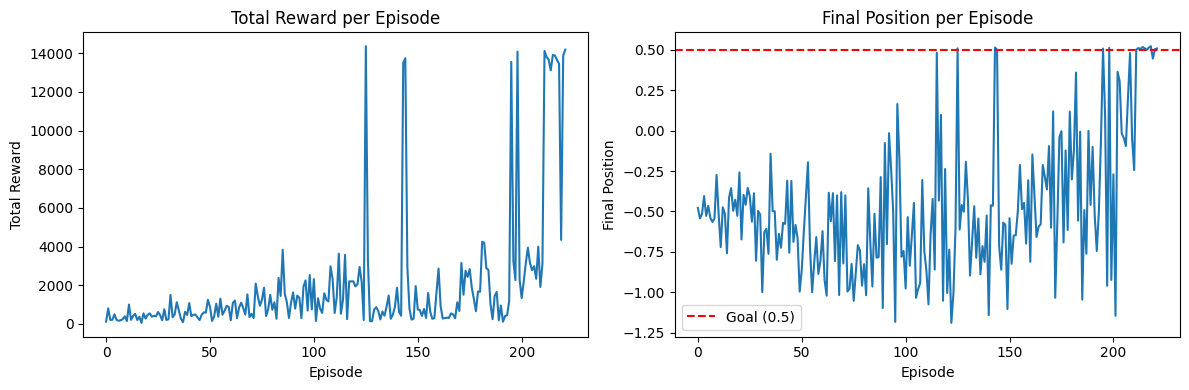


开始测试（可视化：False）...
测试Episode 1 | 步数: 189 | 最终位置: 0.518 | ✅ 成功
测试Episode 2 | 步数: 200 | 最终位置: -0.727 | ❌ 失败
测试Episode 3 | 步数: 191 | 最终位置: 0.518 | ✅ 成功


In [ ]:
import os
import gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

# 修复Linux可视化环境变量
os.environ['XDG_RUNTIME_DIR'] = '/tmp/runtime-' + str(os.getuid())
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# ====================== 1. DQN网络（轻量化+适配归一化状态） ======================
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)  # 简化网络，适配简单场景
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# ====================== 2. DQNAgent（优化超参数+修正优先经验回放） ======================
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 优化超参数（适配MountainCar）
        self.lr = 0.001                # 适度提高学习率，加速收敛
        self.gamma = 0.99              # 保持折扣因子
        self.epsilon = 1.0
        self.epsilon_min = 0.01        # 降低最小探索率，提升利用效率
        self.epsilon_decay = 0.995     # 加快探索率衰减（590轮后≈0.05）
        self.batch_size = 64           # 减小批量，提升初期训练效率
        self.memory = deque(maxlen=50000)  # 减小经验池，提升采样效率
        self.priority_alpha = 0.6      
        
        # 网络初始化
        self.policy_net = DQN(state_size, action_size)
        self.target_net = DQN(state_size, action_size)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.lr)
        self.criterion = nn.MSELoss()
    
    # 状态归一化（关键优化：消除数值范围差异）
    def normalize_state(self, state):
        # 位置范围[-1.2, 0.6] → [0, 1]；速度范围[-0.07, 0.07] → [0, 1]
        pos = (state[0] + 1.2) / 1.8
        vel = (state[1] + 0.07) / 0.14
        return np.array([pos, vel])
    
    # 修正优先经验存储（归一化状态+TD误差计算优化）
    def store_experience(self, state, action, reward, next_state, done):
        state_norm = self.normalize_state(state)
        next_state_norm = self.normalize_state(next_state)
        
        # 用policy_net计算TD误差（仅作为优先级，无需高精度）
        state_t = torch.tensor(state_norm, dtype=torch.float32).unsqueeze(0)
        next_state_t = torch.tensor(next_state_norm, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            current_q = self.policy_net(state_t)[0][action]
            next_q = self.target_net(next_state_t).max(1)[0]
            td_error = abs(reward + self.gamma * next_q * (1 - done) - current_q) + 1e-6  # 避免0优先级
        self.memory.append((td_error.item(), state_norm, action, reward, next_state_norm, done))
    
    # 优先经验采样（保持逻辑，适配小批量）
    def sample_priority_batch(self):
        if len(self.memory) < self.batch_size:
            return None
        priorities = np.array([exp[0] for exp in self.memory])
        sampling_probs = priorities ** self.priority_alpha
        sampling_probs /= sampling_probs.sum()
        
        batch_indices = np.random.choice(len(self.memory), self.batch_size, p=sampling_probs)
        batch = [self.memory[i] for i in batch_indices]
        
        td_errors, states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(states, dtype=torch.float32),
            torch.tensor(actions, dtype=torch.long).unsqueeze(1),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(next_states, dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32)
        )
    
    def choose_action(self, state):
        state_norm = self.normalize_state(state)
        if random.uniform(0, 1) < self.epsilon:
            return random.randrange(self.action_size)
        state_t = torch.tensor(state_norm, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            q_values = self.policy_net(state_t)
        return torch.argmax(q_values).item()
    
    def update_policy(self):
        batch = self.sample_priority_batch()
        if batch is None:
            return
        
        states, actions, rewards, next_states, dones = batch
        
        # 计算Q值（保持逻辑）
        current_q = self.policy_net(states).gather(1, actions)
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
            target_q = rewards.unsqueeze(1) + self.gamma * next_q * (1 - dones.unsqueeze(1))
        
        # 反向传播（梯度裁剪阈值调整为0.5）
        loss = self.criterion(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 0.5)
        self.optimizer.step()
    
    def sync_target_net(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())
    
    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ====================== 3. 训练函数（核心优化：奖励函数+监控） ======================
def train_agent(episodes=800, target_sync_freq=10):  # 提高目标网络同步频率
    env = gym.make('MountainCar-v0')
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n
    agent = DQNAgent(state_size, action_size)
    
    # 监控指标
    success_count = 0
    success_episodes = []
    total_rewards = []
    final_positions = []
    min_steps_to_goal = 200
    
    print("开始训练（优化奖励+状态归一化）...")
    for episode in range(episodes):
        state = env.reset()
        state = state[0] if isinstance(state, tuple) else state
        total_reward = 0
        done = False
        step = 0
        episode_success = False
        
        while not done and step < 200:
            action = agent.choose_action(state)
            next_state, _, done, _, _ = env.step(action)
            
           
            pos = next_state[0]
            vel = next_state[1]
            
            # 1. 位置奖励：非线性激励（越接近目标，奖励增长越快）
            pos_reward = 100 * (pos + 0.5) ** 2  # 位置-0.5→0，0.5→100
            # 2. 速度奖励：与位置方向挂钩（向目标移动时速度奖励翻倍）
            vel_reward = 500 * abs(vel) if pos > -0.3 else 100 * abs(vel)
            # 3. 登顶奖励：大幅提高，确保强激励
            reward = pos_reward + vel_reward
            if pos >= 0.5:
                reward += 10000  # 登顶奖励从5000提升到10000
                episode_success = True
                min_steps_to_goal = min(min_steps_to_goal, step+1)
                done = True
        
            agent.store_experience(state, action, reward, next_state, done)
            agent.update_policy()
            state = next_state
            total_reward += reward
            step += 1
        
        # 修正成功判定（直接基于最终位置）
        if next_state[0] >= 0.5:
            episode_success = True
        
        # 统计成功数
        if episode_success:
            success_count += 1
            success_episodes.append(episode+1)
        
        # 记录指标
        total_rewards.append(total_reward)
        final_positions.append(next_state[0])
        agent.decay_epsilon()
        
        # 同步目标网络（频率从20→10）
        if episode % target_sync_freq == 0:
            agent.sync_target_net()
        
        # 打印进度（增加最终位置，方便调试）
        if (episode+1) % 10 == 0:
            avg_reward = np.mean(total_rewards[-10:])
            avg_position = np.mean(final_positions[-10:])
            print(f"Episode {episode+1:4d} | 平均奖励: {avg_reward:6.1f} | 平均位置: {avg_position:.3f} | 探索率: {agent.epsilon:.3f} | 累计成功: {success_count}")
        
        # 终止条件：连续10轮成功（确保稳定）
        if len(success_episodes) >= 10 and success_episodes[-10] >= episode-9:
            print(f"\n✅ 训练完成！第{episode+1}轮稳定登顶，最少步数：{min_steps_to_goal}")
            break
    
    # 绘制监控曲线（保持逻辑）
    plt.figure(figsize=(12, 4))
    plt.subplot(1,2,1)
    plt.plot(total_rewards)
    plt.title('Total Reward per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    
    plt.subplot(1,2,2)
    plt.plot(final_positions)
    plt.axhline(y=0.5, color='r', linestyle='--', label='Goal (0.5)')
    plt.title('Final Position per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Final Position')
    plt.legend()
    plt.tight_layout()
    plt.savefig('mountain_car_training_optimized.png')
    plt.show()
    
    torch.save(agent.policy_net.state_dict(), "mountain_car_dqn_optimized.pth")
    env.close()
    return agent

# ====================== 4. 测试函数（适配归一化） ======================
def test_agent(agent, episodes=3, use_visual=False):
    env = gym.make('MountainCar-v0', render_mode='human') if use_visual else gym.make('MountainCar-v0')
    agent.epsilon = 0.0  # 关闭探索
    print(f"\n开始测试（可视化：{use_visual}）...")
    
    for episode in range(episodes):
        state = env.reset()
        state = state[0] if isinstance(state, tuple) else state
        done = False
        total_reward = 0
        step = 0
        
        while not done and step < 200:
            if use_visual:
                env.render()
            action = agent.choose_action(state)
            next_state, _, done, _, _ = env.step(action)
            
            # 测试奖励（与训练一致）
            pos = next_state[0]
            vel = next_state[1]
            reward = 100 * (pos + 0.5) ** 2 + (500 * abs(vel) if pos > -0.3 else 100 * abs(vel))
            if pos >= 0.5:
                reward += 10000
                done = True
            
            total_reward += reward
            state = next_state
            step += 1
        
        success = "✅ 成功" if next_state[0] >= 0.5 else "❌ 失败"
        print(f"测试Episode {episode+1} | 步数: {step} | 最终位置: {next_state[0]:.3f} | {success}")
    
    env.close()

# ====================== 主程序 ======================
if __name__ == "__main__":
    # 训练
    trained_agent = train_agent(episodes=800)
    # 测试
    test_agent(trained_agent, episodes=3, use_visual=False)